In [5]:
import qgauss as qg
import numpy as np
import matplotlib.pyplot as plt

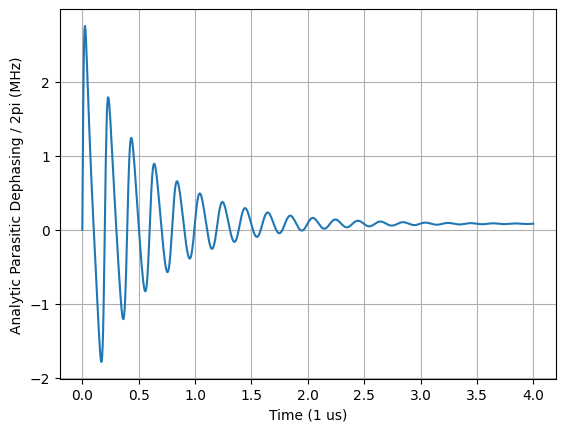

In [72]:
""" In this example, we will compare the results of the backaction time-evolution with known analytic expressions. 
The example is that of a single oscillator dispersively coupled to a single qubit, detailed in the paper:
    Clerk & Utami. Using a qubit to measure photon-number statistics of a driven thermal oscillator. 
    Phys. Rev. A 75, 042302 (2007). DOI: https://doi.org/10.1103/PhysRevA.75.042302
In this work, an analytic expression for the time-dependent and steady-state parasitic dephasing resulting from 
thermal fluctuations in the bath of the oscillator are derived. Although the focus is on dephasing, ac-Stark can
also be extracted from these simulations.
"""
# We will begin by plotting the analytic results.
def clerk_utami_para_deph(chi, gamma, nth, t):
    _alpha = np.sqrt(np.pow(1 - 1j*gamma/(2*chi),2) - 2j*gamma*nth/chi)
    _exp_z = nth/(nth+1)
    _M = (2*_exp_z + (_exp_z - 1)*(_alpha - 1 + 0.5j*gamma/chi))/(2 + (_exp_z - 1)*(-_alpha + 1 + 0.5j*gamma/chi))
    return -0.5*gamma + 1j*chi*_alpha*(1 + _M*np.exp(-2j*chi*_alpha*t))/(1 - _M*np.exp(-2j*chi*_alpha*t))

# Parameters. We choose a weakly damped cavity with large thermal occupation to demonstrate the large oscillations.
chi = 2*np.pi*2.5
lw = 2*np.pi*0.1
nthm = 0.8
tlist = np.linspace(0, 4, 1001)

clerk_utami_para_deph_vals = np.real(clerk_utami_para_deph(chi, lw, nthm, tlist))/(2*np.pi)

fig, ax = plt.subplots()
ax.plot(tlist, clerk_utami_para_deph_vals);
ax.set(xlabel='Time (1 us)', ylabel='Analytic Parasitic Dephasing / 2pi (MHz)',
       title='');
ax.grid();
plt.show()

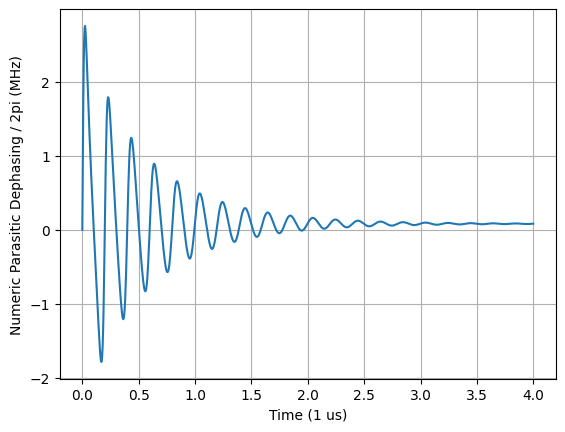

In [80]:
# We now proceed to demonstrate the results using the qgauss package. For more details on setting up the operators,
# refer to Example_Backaction_Steady_State.ipynb

c = qg.tensor(qg.destroy(),qg.identity_fls(2))
sz = qg.tensor(qg.identity_cvs(),qg.sigmaz())

rhod_thm = qg.tensor(qg.thermal(nthm),qg.qubit_plus())
H_disp = chi*c.dag()*c*sz
L_thrm = (qg.coherent(H_disp)
          + lw*(nthm+1)*qg.dissipator(c)
          + lw*nthm*qg.dissipator(c.dag()))

thm_deph_time = qg.backaction_timeevolve(L_thrm, rho0=rhod_thm, tlist=tlist, elem=(0,1))

fig, ax = plt.subplots()
ax.plot(tlist, np.real(thm_deph_time[4])/(2*np.pi));
ax.set(xlabel='Time (1 us)', ylabel='Numeric Parasitic Dephasing / 2pi (MHz)',
       title='');
ax.grid();
plt.show()

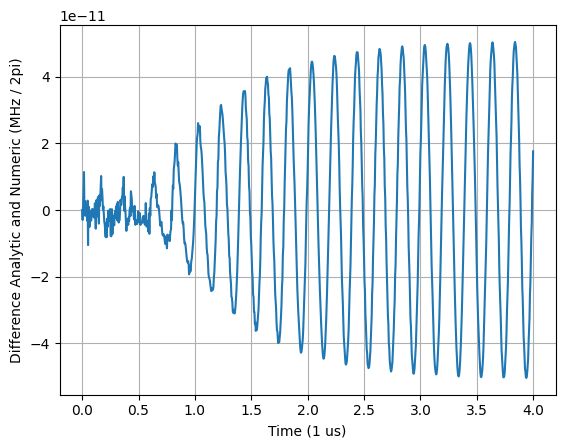

In [81]:
# We can finally compare the accuracy of the numeric and analytic results, which are identical within numerical error.
# The accuracy of the numerical results can be improved by using smaller atol and rtol options.
fig, ax = plt.subplots()
ax.plot(tlist, clerk_utami_para_deph_vals - np.real(thm_deph_time[4])/(2*np.pi));
ax.set(xlabel='Time (1 us)', ylabel='Difference Analytic and Numeric (MHz / 2pi)',
       title='');
ax.grid();
plt.show()

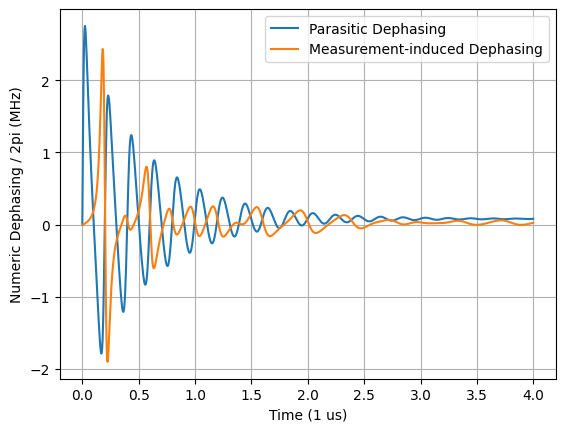

In [75]:
# We will now add some time-dependence to this system. To do this, we structure the time-dependent component as:
#    list[[QGsuper, Callable]].
# The second argument must be a function, and so lists of discrete values should be converted to the Callable type
# through the use of an interpolation function. For this example, we will add a drive term.
# A simple method is to just do as follows:
freq_d = 1/2 
def drive(t): return 5*np.exp(-1j*np.pi*freq_d*t)
def drive_dag(t): return 5*np.exp(1j*np.pi*freq_d*t)
L_drv_1 = [[qg.coherent(c), drive], [qg.coherent(c.dag()), drive_dag]]

# One drawback of this approach is that using non-Hermitian operators in the time-dependent component will currently
# call the less-efficient solver when solving for the moments of true-quantum states. In order to avoid this, it is
# recommended to use Hermitian operators, such as follows:
q = qg.tensor(qg.position(),qg.identity_fls(2))
p = qg.tensor(qg.momentum(),qg.identity_fls(2))
L_drv_2 = [[qg.coherent(q), lambda t: 5*np.cos(np.pi*freq_d*t)] ,
           [qg.coherent(p), lambda t: 5*np.sin(np.pi*freq_d*t)]]

thm_drv_deph_time = qg.backaction_timeevolve(L0=L_thrm, Lt=L_drv_2, rho0=rhod_thm, tlist=tlist, elem=(0,1))

fig, ax = plt.subplots()
ax.plot(tlist, np.real(thm_drv_deph_time[4])/(2*np.pi));
ax.plot(tlist, np.real(thm_drv_deph_time[3])/(2*np.pi));
ax.set(xlabel='Time (1 us)', ylabel='Numeric Dephasing / 2pi (MHz)',title='');
ax.legend(("Parasitic Dephasing","Measurement-induced Dephasing"));
ax.grid();
plt.show()

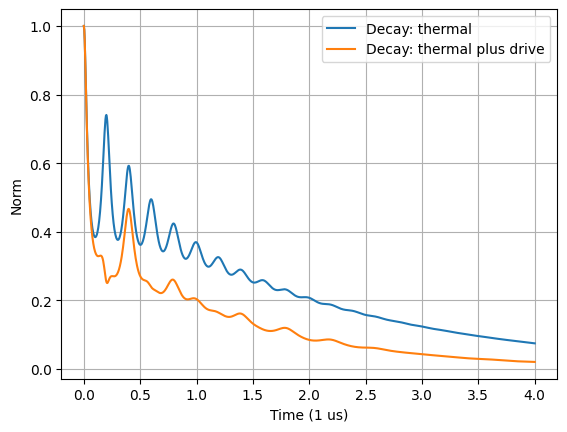

In [82]:
# We can also track the effect of induced dephasing through the decay of the qubit-coherence. For this, we take
# the absolute value of the off-diagonal term in the reduced qubit density matrix, that is, the decay of the norm.
# The total-integrated dephasing is then the log of this number.
fig, ax = plt.subplots()
ax.plot(tlist, np.abs(thm_deph_time[0]));
ax.plot(tlist, np.abs(thm_drv_deph_time[0]));
ax.set(xlabel='Time (1 us)', ylabel='Norm',title='');
ax.legend(("Decay: thermal","Decay: thermal plus drive"));
ax.grid();
plt.show()